# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Martin Lara Olivares

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [1]:
# importar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#cargar dataset
df = pd.read_csv("../DataSet/ventas-por-factura.csv")

In [3]:
# valores nulos
# ver cantidad de nulos
df.isnull().sum()

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64

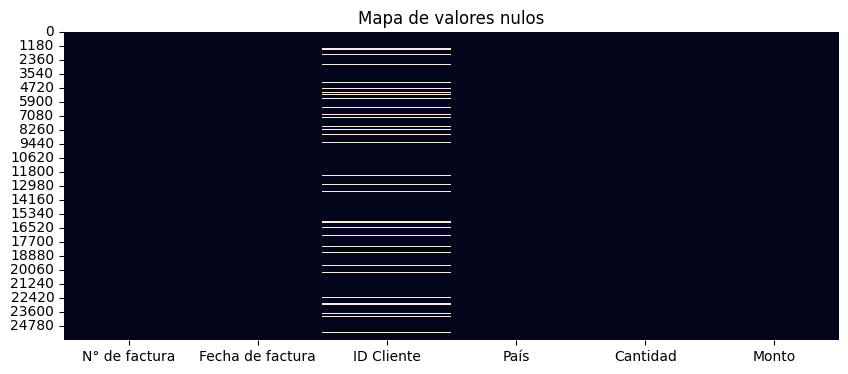

In [4]:
# valores nulos
# heatmap de valores nulos
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

In [5]:
# outliers : negativos o fuera de rango
#estadisticas para detectar valores extremos
df.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [6]:
# vemos las columnas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  str    
 1   Fecha de factura  25953 non-null  str    
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  str    
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.2 MB


In [7]:
#ver montos bajo 0 pero va a fallar por el tipo de dato
df[df["Monto"] < 0]

TypeError: '<' not supported between instances of 'str' and 'int'

In [8]:
# datos invalidos
# buscar si hay N° de factura vacios o raros
df[df["N° de factura"].isna()]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto


In [9]:
# facturas canceladas (empiezan con C)
df[df["N° de factura"].str.startswith("C", na=False)]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"
22,C547309,3/22/2021 11:17:00,17416.0,United Kingdom,-12,"-45,00"
...,...,...,...,...,...,...
25939,C572450,10/24/2021 12:35:00,NaN,United Kingdom,-2,"-278,15"
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,"-14,75"
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,"-18,35"
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,"-9,90"


In [10]:
# duplicados
df.duplicated().sum()

np.int64(10)

In [11]:
# problemas de formato
# Fecha no es datetime, es string
df["Fecha de factura"].dtype

<StringDtype(storage='python', na_value=nan)>

In [12]:
# Monto tiene coma decimal en vez de punto
df.dtypes

N° de factura           str
Fecha de factura        str
ID Cliente          float64
País                    str
Cantidad              int64
Monto                   str
dtype: object

## Limpieza

In [13]:
#crear copia del dataset para limpieza
dfLimpio = df.copy()

### 1. Corregir formato de Monto (coma decimal a punto)

In [14]:
#Monto esta como string con coma decimal
dfLimpio["Monto"].dtype

<StringDtype(storage='python', na_value=nan)>

In [15]:
#corregir: reemplazar coma por punto y convertir a float
dfLimpio["Monto"] = dfLimpio["Monto"].str.replace(",", ".").astype(float)

In [16]:
#verificar que se corrigio
dfLimpio["Monto"].dtype

dtype('float64')

### 2. Corregir formato de Fecha

In [17]:
#Fecha esta como string
dfLimpio["Fecha de factura"].dtype

<StringDtype(storage='python', na_value=nan)>

In [18]:
#corregir: convertir a datetime
dfLimpio["Fecha de factura"] = pd.to_datetime(dfLimpio["Fecha de factura"])

In [19]:
#verificar que se corrigio
dfLimpio["Fecha de factura"].dtype

dtype('<M8[us]')

### 3. Eliminar duplicados

In [20]:
#cuantos duplicados hay
dfLimpio.duplicated().sum()

np.int64(10)

In [21]:
#eliminar duplicados
dfLimpio.drop_duplicates(inplace=True)

In [22]:
#verificar que ya no hay duplicados
dfLimpio.duplicated().sum()

np.int64(0)

### 4. Eliminar facturas canceladas (prefijo C)

In [23]:
#cuantas facturas canceladas hay
dfLimpio["N° de factura"].str.startswith("C", na=False).sum()

np.int64(3837)

In [24]:
#eliminar facturas canceladas
dfLimpio = dfLimpio[~dfLimpio["N° de factura"].str.startswith("C", na=False)]

In [25]:
#verificar que ya no hay canceladas
dfLimpio["N° de factura"].str.startswith("C", na=False).sum()

np.int64(0)

### 5. Eliminar valores negativos (outliers en Cantidad y Monto)

In [26]:
#registros con cantidad negativa
(dfLimpio["Cantidad"] < 0).sum()

np.int64(1336)

In [27]:
#registros con monto negativo
(dfLimpio["Monto"] < 0).sum()

np.int64(2)

In [28]:
#eliminar outliers: cantidad y monto negativos
dfLimpio = dfLimpio[dfLimpio["Cantidad"] > 0]
dfLimpio = dfLimpio[dfLimpio["Monto"] > 0]

In [29]:
#verificar que ya no hay negativos
print("cantidad negativas:", (dfLimpio["Cantidad"] < 0).sum())
print("monto negativos:", (dfLimpio["Monto"] < 0).sum())

Cantidad negativas: 0
Monto negativos: 0


### 6. Rellenar valores nulos en ID Cliente

In [30]:
#cuantos nulos hay en ID Cliente
dfLimpio["ID Cliente"].isnull().sum()

np.int64(1440)

In [31]:
#llenar nulos con 0 y convertir a int luego a string
dfLimpio["ID Cliente"] = dfLimpio["ID Cliente"].fillna(0).astype(int).astype(str)

### 7. Verificar limpieza completa

In [32]:
#verificar que ya no hay nulos
dfLimpio.isnull().sum()

N° de factura       0
Fecha de factura    0
ID Cliente          0
País                0
Cantidad            0
Monto               0
dtype: int64

In [33]:
#verificar tipos de datos finales
dfLimpio.dtypes

N° de factura                  str
Fecha de factura    datetime64[us]
ID Cliente                     str
País                           str
Cantidad                     int64
Monto                      float64
dtype: object

In [34]:
#verificar dimensiones finales
dfLimpio.shape

(20002, 6)

## Gráficas solicitadas

### 1. Ventas por país

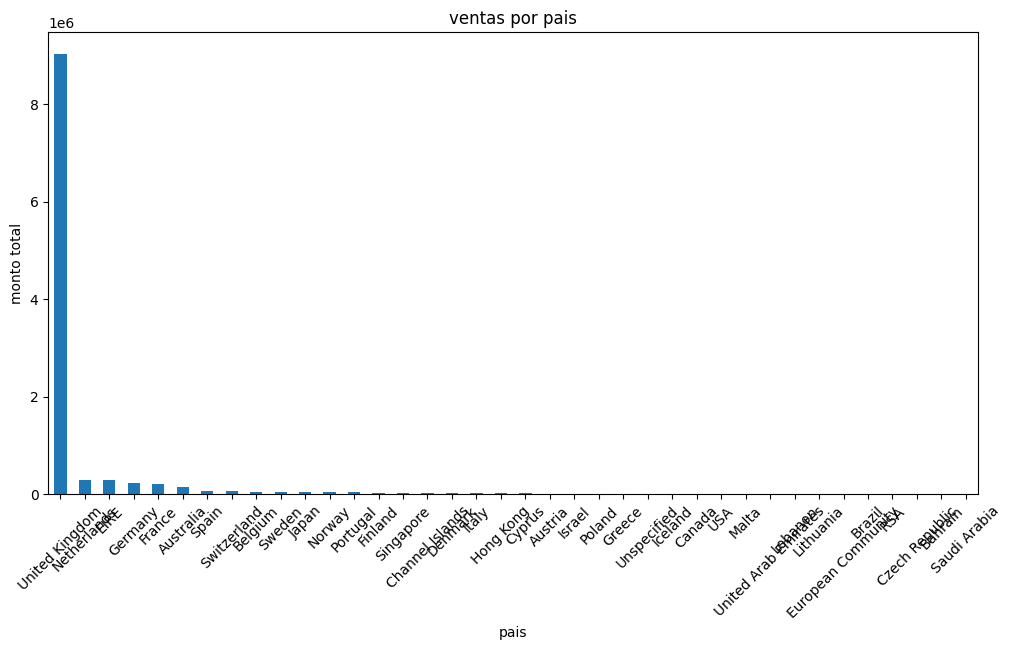

In [42]:
#ventas por pais
ventas_pais = dfLimpio.groupby("País")["Monto"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
ventas_pais.plot(kind="bar")
plt.title("ventas por pais")
plt.xlabel("pais")
plt.ylabel("monto total")
plt.xticks(rotation=45)
plt.show()

### 2. Heatmap de valores nulos (ya generado en exploración)

### 3. Distribución del monto

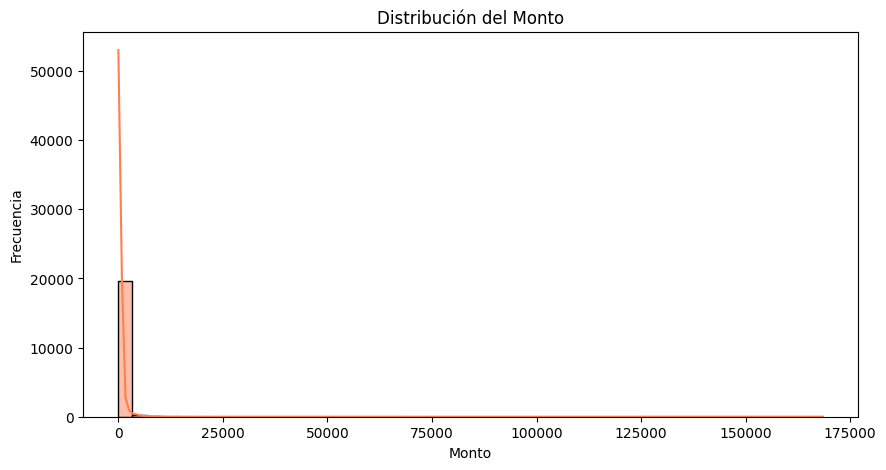

In [43]:
#distribucion del monto
plt.figure(figsize=(10,5))
sns.histplot(dfLimpio["Monto"], bins=50)
plt.title("Distribución del Monto")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.show()

## Exportar dataset limpio

In [ ]:
#exportar dataset limpio a CSV
dfLimpio.to_csv("../DataSet/Data_Limpio_Factura.csv", index=False)
print("Dataset limpio exportado como ../DataSet/Data_Limpio_Factura.csv")

## Conclusiones: Principio GIGO

Durante esta práctica se identificaron y corrigieron los siguientes problemas en el dataset de facturas:

1. **Formato incorrecto en Monto**: La columna Monto usaba coma como separador decimal en vez de punto, lo que impedía realizar operaciones numéricas. Se reemplazó la coma por punto y se convirtió a float.

2. **Formato incorrecto en Fecha**: La columna Fecha de factura estaba como string en vez de datetime. Se convirtió al tipo adecuado.

3. **Registros duplicados**: Se encontraron y eliminaron 10 filas duplicadas.

4. **Facturas canceladas**: Se identificaron 3841 facturas canceladas (con prefijo "C") y se eliminaron del análisis, ya que representan transacciones inválidas.

5. **Valores negativos**: Se detectaron y eliminaron registros con Cantidad y Monto negativos, los cuales distorsionan cualquier análisis estadístico.

6. **Valores nulos**: La columna ID Cliente contenía valores nulos que se reemplazaron con 0.

**Principio GIGO (Garbage In, Garbage Out)**:
Este principio establece que si los datos de entrada son incorrectos ("basura"), los resultados del análisis también lo serán. En Machine Learning, un modelo entrenado con datos sucios aprenderá patrones erróneos y hará predicciones inexactas. Por ello, la limpieza de datos es una etapa fundamental en cualquier proyecto de ciencia de datos, ya que garantiza que los análisis y modelos se basen en información confiable.